## Cost Landscape Exploration

&nbsp;

### Read the csv containing results from cost exploration:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("cost_exploration/yahpo_costs_train20.csv")
df["val_accuracy_scaled"] = df["val_accuracy"] * 0.01

### Get percentiles:

In [2]:
df["time"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95])

count    20000.000000
mean       269.836260
std        794.825975
min          8.320948
10%         49.826944
25%         72.275209
50%        123.880032
75%        245.530502
90%        599.726196
95%        866.830728
max      38462.175781
Name: time, dtype: float64

&nbsp;

### Grouping by instance:

In [3]:
df.groupby("instance")["time"].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95]
)

,count,mean,std,min,10%,25%,50%,75%,90%,95%,max
instance,,,,,,,,,,,
3945,1000.0,245.770203,247.261699,43.542484,75.011228,115.062094,183.171516,269.809990,476.969037,645.526889,2878.204346
7593,1000.0,1681.759727,3056.204188,425.839386,575.754144,685.346848,929.247406,1502.606689,2729.530981,4362.041650,38462.175781
34539,1000.0,132.062786,117.841198,31.686695,60.463409,74.757715,91.512974,138.414936,246.966591,360.977068,1176.124512
126025,1000.0,160.787477,190.499126,34.525837,66.854827,77.457756,98.800476,168.295307,312.944446,459.609424,3381.067139
126026,1000.0,169.977794,159.756379,23.437008,55.808526,76.910429,114.610287,192.621143,368.577408,501.898000,1455.452271
126029,1000.0,160.909893,253.527423,35.474079,63.894086,74.764683,98.927372,164.093765,312.692621,474.291241,6160.429199
146212,1000.0,205.127815,264.718220,16.739368,41.628434,64.729376,116.091911,218.136467,477.168866,703.624121,2685.863525
167104,1000.0,87.340566,100.822390,11.267465,21.934328,28.828032,52.995600,94.602774,199.057886,311.438081,907.464417
167149,1000.0,92.167025,84.189011,8.320948,27.951886,38.674040,62.675318,108.673330,209.225531,268.102661,895.898682


&nbsp;

### Correlations:

In [4]:
cols = [
    "time",
    "val_accuracy",
    "batch_size",
    "learning_rate",
    "max_dropout",
    "max_units",
    "momentum",
    "num_layers",
    "weight_decay",
]


df[cols].corr(numeric_only=True)["time"].sort_values(ascending=False)

time             1.000000
max_units        0.166835
num_layers       0.166240
weight_decay     0.037167
learning_rate    0.035420
momentum         0.020927
max_dropout     -0.032783
batch_size      -0.056275
val_accuracy    -0.110949
Name: time, dtype: float64

&nbsp;

### Count how many evaluations you could take under different budgets:

In [5]:
def evals_until_budget(costs, budget, n_repeats=1000, seed=0):
    rng = np.random.default_rng(seed)
    counts = []

    costs = np.asarray(costs)

    for _ in range(n_repeats):
        order = rng.permutation(costs)
        cumulative = np.cumsum(order)
        count = np.searchsorted(cumulative, budget, side="right")
        counts.append(count)

    return np.array(counts)


budgets = [2500, 4000, 5000, 8000, 10000]
rows = []

for instance, g in df.groupby("instance"):
    for budget in budgets:
        counts = evals_until_budget(g["time"].values, budget)
        rows.append(
            {
                "instance": instance,
                "budget": budget,
                "mean_evals": counts.mean(),
                "median_evals": np.median(counts),
                "p10_evals": np.quantile(counts, 0.1),
                "p90_evals": np.quantile(counts, 0.9),
            }
        )

eval_counts = pd.DataFrame(rows)
eval_counts

,instance,budget,mean_evals,median_evals,p10_evals,p90_evals
0,3945,2500,10.236,10.0,6.0,14.0
1,3945,4000,16.353,17.0,11.0,21.0
2,3945,5000,20.362,21.0,15.0,26.0
3,3945,8000,32.437,33.0,25.0,39.0
4,3945,10000,40.576,41.0,32.9,48.0
...,...,...,...,...,...,...
95,168330,2500,9.106,9.0,5.0,13.0
96,168330,4000,14.424,15.0,9.0,19.1
97,168330,5000,18.007,18.0,12.0,24.0
98,168330,8000,28.483,29.0,20.0,36.0


&nbsp;

&nbsp;

&nbsp;

&nbsp;

### Plots:

#### Distributions:

##### Median Evaluation Distribution by Instance (Train20):

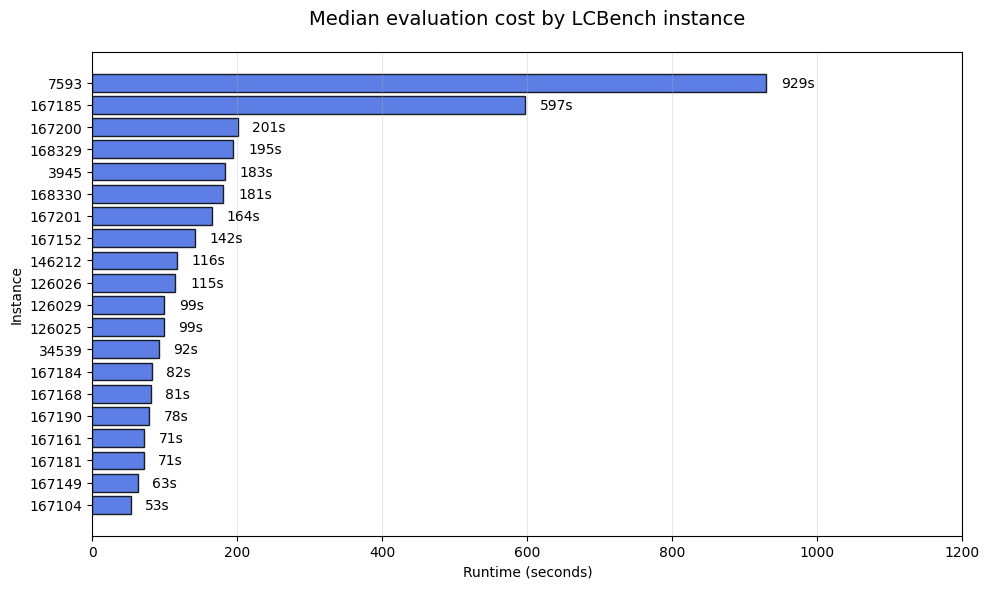

In [6]:
median_times = (
    df.groupby("instance")["time"]
    .median()
    .sort_values(ascending=True)   # ascending=True puts smallest on top (like your plot)
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    y=median_times.index.astype(str), 
    width=median_times.values, 
    color='royalblue',
    edgecolor='black',
    alpha=0.85
)

plt.title("Median evaluation cost by LCBench instance", fontsize=14, pad=20)
plt.xlabel("Runtime (seconds)")
plt.ylabel("Instance")

for bar in bars:
    width = bar.get_width()
    plt.text(width + 20, bar.get_y() + bar.get_height()/2, 
             f'{width:.0f}s', 
             va='center', fontsize=10)

plt.grid(axis='x', alpha=0.3)
plt.xlim([0, 1200])
plt.tight_layout()
plt.show()

&nbsp;

&nbsp;



##### Mean Evaluation Distribution by Instance (Train20):

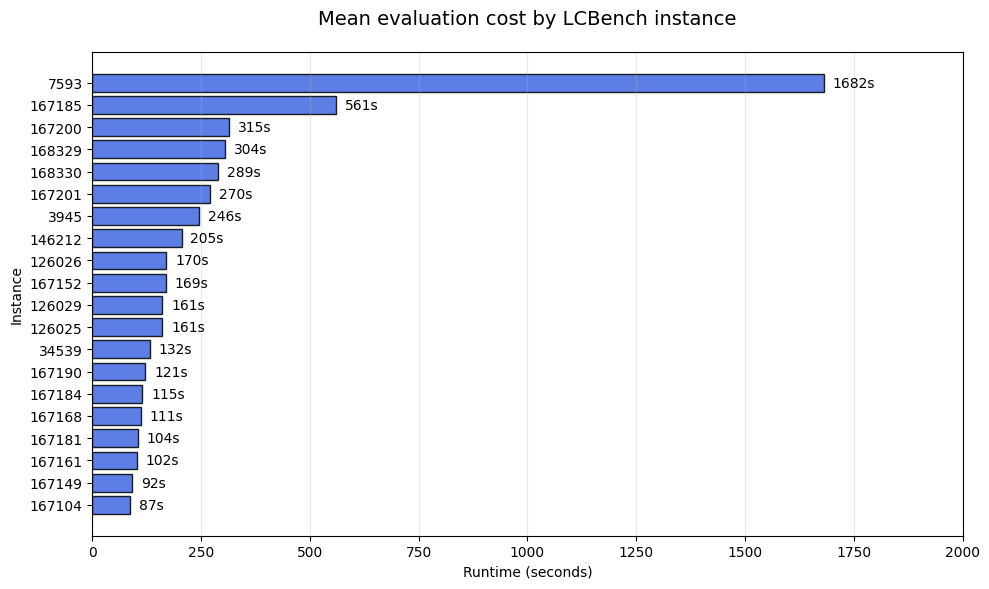

In [7]:
mean_times = (
    df.groupby("instance")["time"]
    .mean()
    .sort_values(ascending=True)   # ascending=True puts smallest on top (like your plot)
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    y=mean_times.index.astype(str), 
    width=mean_times.values, 
    color='royalblue',
    edgecolor='black',
    alpha=0.85
)

plt.title("Mean evaluation cost by LCBench instance", fontsize=14, pad=20)
plt.xlabel("Runtime (seconds)")
plt.ylabel("Instance")

for bar in bars:
    width = bar.get_width()
    plt.text(width + 20, bar.get_y() + bar.get_height()/2, 
             f'{width:.0f}s', 
             va='center', fontsize=10)

plt.grid(axis='x', alpha=0.3)
plt.xlim([0, 2000])
plt.tight_layout()
plt.show()

&nbsp;

&nbsp;



##### Cost Distribution - Train20:

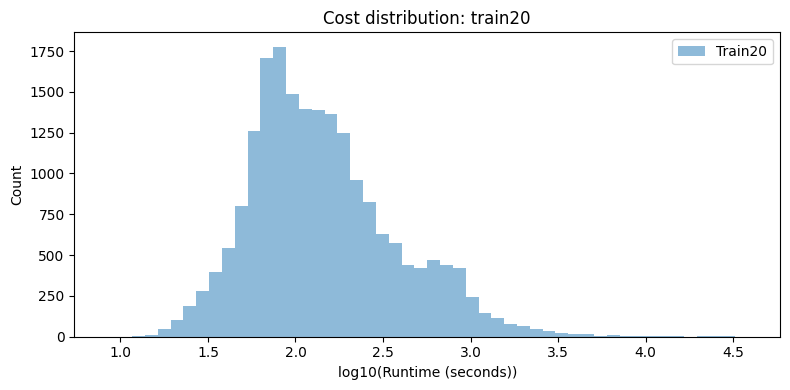

In [8]:
plt.figure(figsize=(8, 4))
plt.hist(np.log10(df["time"]), bins=50, alpha=0.5, label="Train20")
plt.xlabel("log10(Runtime (seconds))")
plt.ylabel("Count")
plt.title("Cost distribution: train20")
plt.legend()
plt.tight_layout()
plt.show()

&nbsp;

&nbsp;



##### Expected number of evaluations under different budgets:

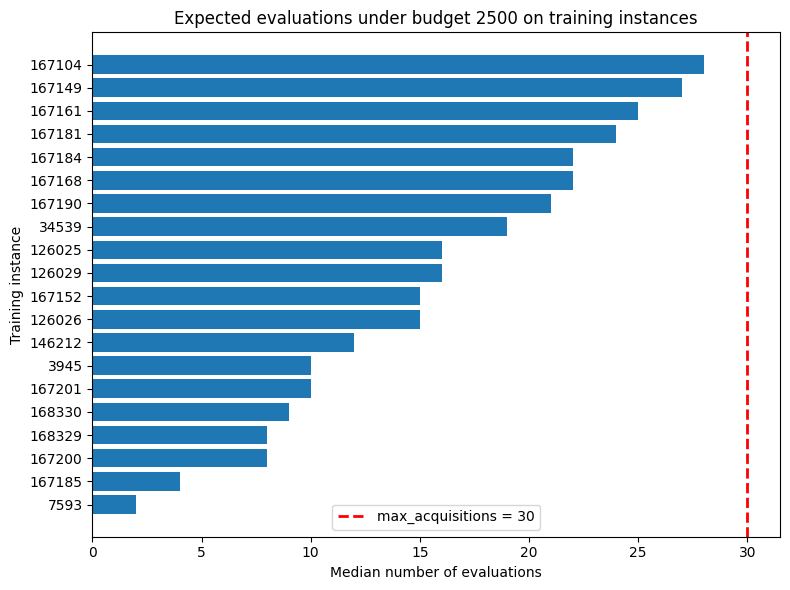

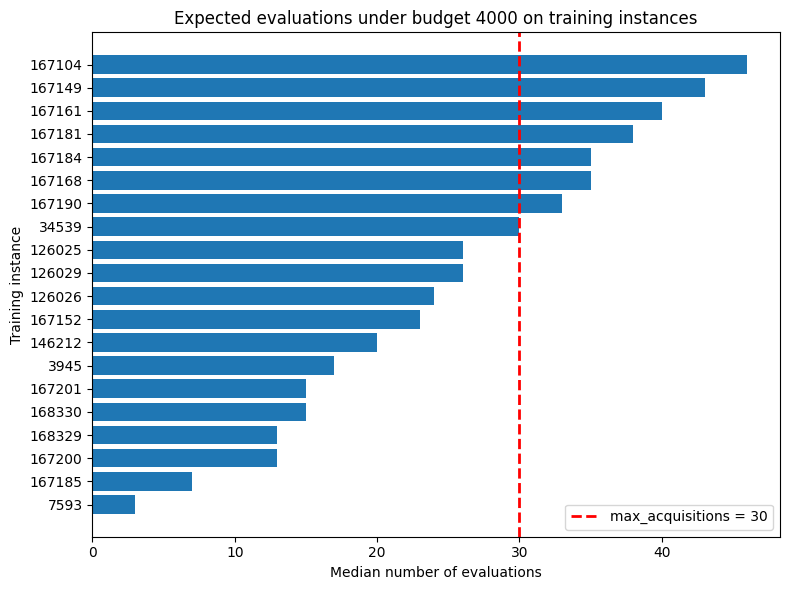

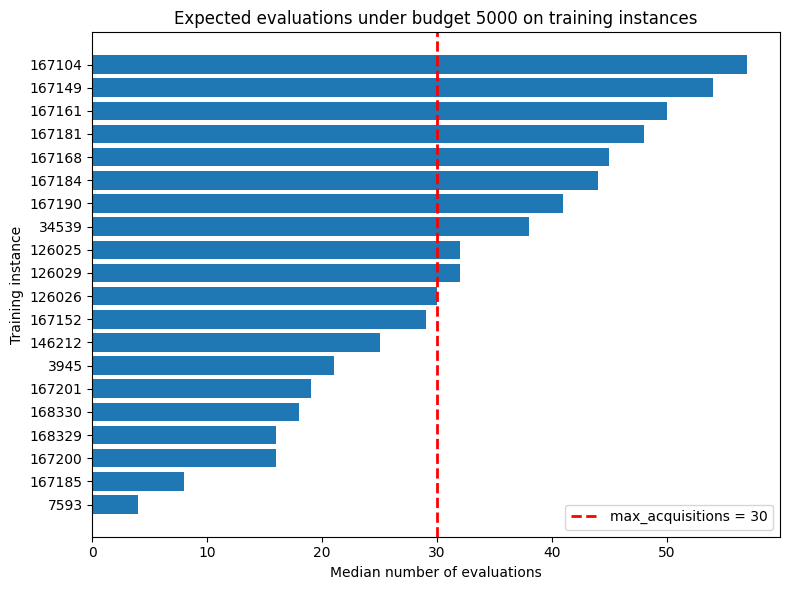

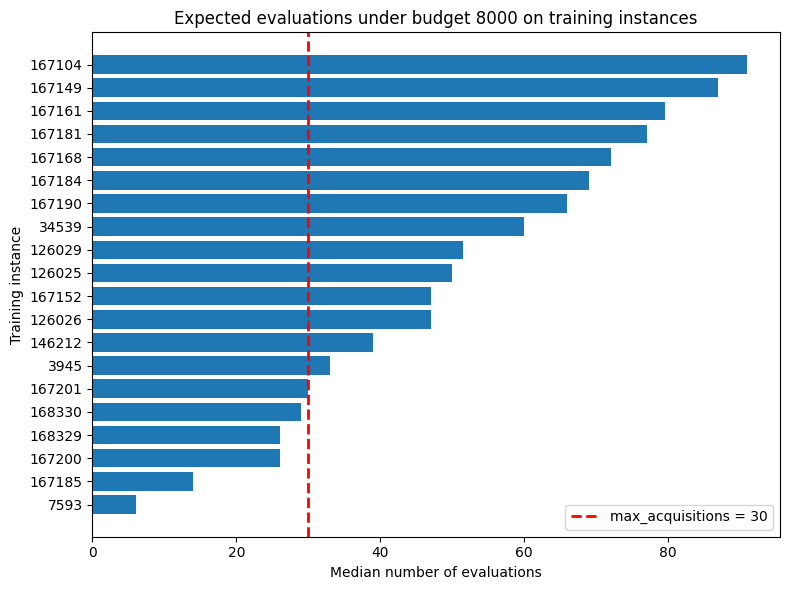

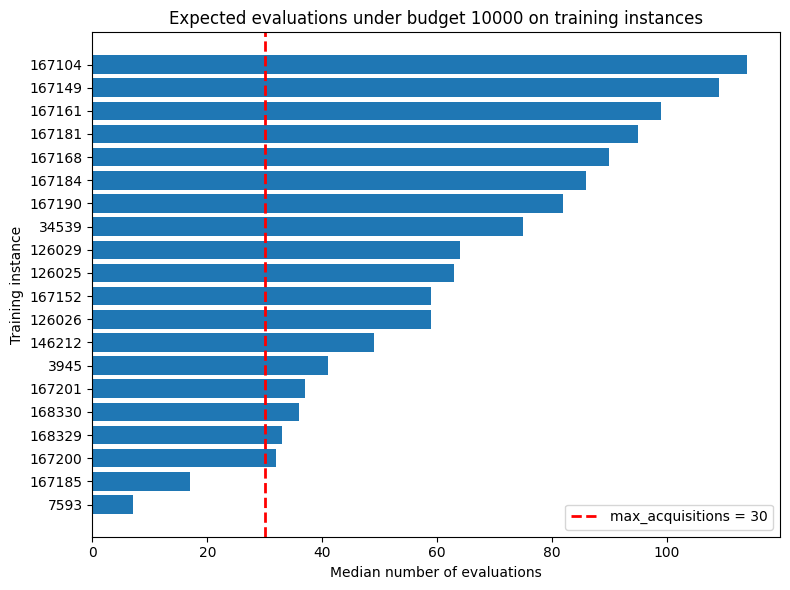

In [9]:
MAX_ACQUISITIONS = 30

for budget in budgets:
    sub = eval_counts[eval_counts["budget"] == budget].sort_values("median_evals")

    plt.figure(figsize=(8, 6))
    plt.barh(sub["instance"].astype(str), sub["median_evals"])

    plt.axvline(
        x=MAX_ACQUISITIONS,
        linestyle="--",
        color="red",
        linewidth=2,
        label=f"max_acquisitions = {MAX_ACQUISITIONS}",
    )

    plt.xlabel("Median number of evaluations")
    plt.ylabel("Training instance")
    plt.title(f"Expected evaluations under budget {budget} on training instances")
    plt.legend()
    plt.tight_layout()
    plt.show()

&nbsp;

&nbsp;




##### Cost vs validation accuracy scatter:

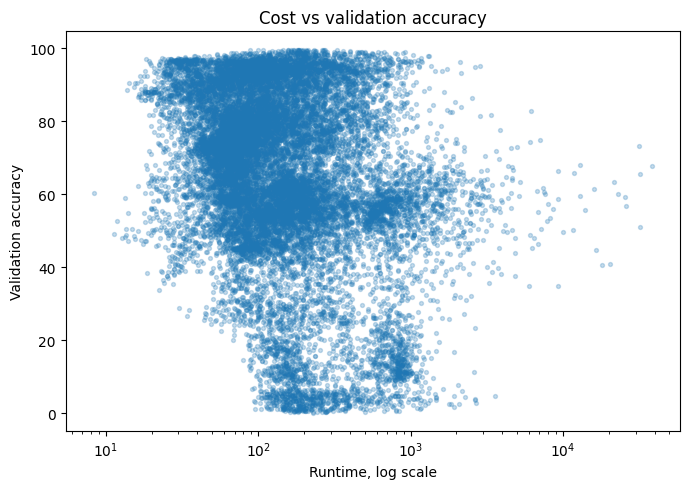

In [10]:
plt.figure(figsize=(7, 5))
plt.scatter(df["time"], df["val_accuracy"], alpha=0.25, s=8)
plt.xscale("log")
plt.xlabel("Runtime, log scale")
plt.ylabel("Validation accuracy")
plt.title("Cost vs validation accuracy")
plt.tight_layout()
plt.show()

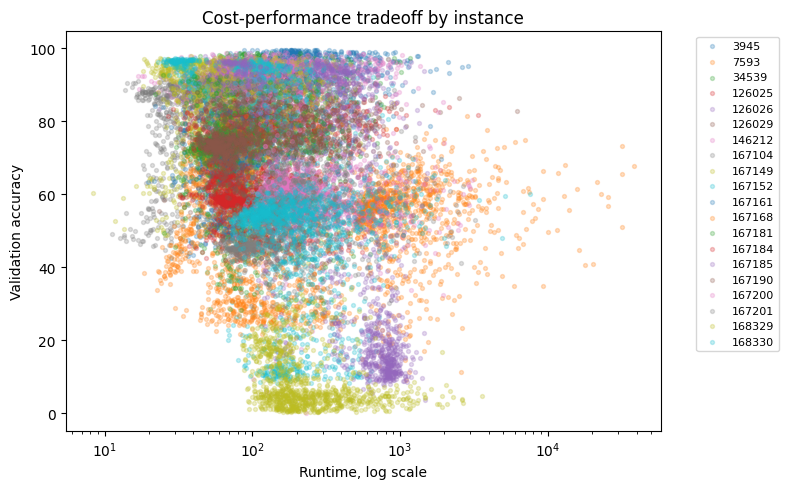

In [11]:
plt.figure(figsize=(8, 5))
for instance, g in df.groupby("instance"):
    plt.scatter(g["time"], g["val_accuracy"], alpha=0.25, s=8, label=str(instance))

plt.xscale("log")
plt.xlabel("Runtime, log scale")
plt.ylabel("Validation accuracy")
plt.title("Cost-performance tradeoff by instance")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

&nbsp;

&nbsp;

##### Pareto frontier plot

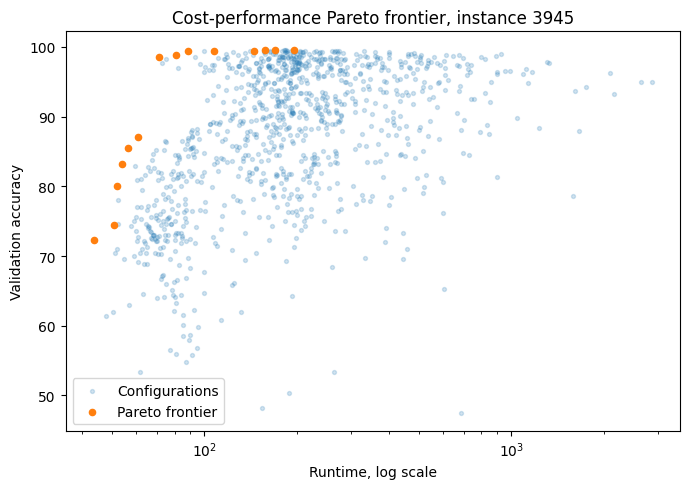

In [12]:
def pareto_frontier(df, cost_col="time", obj_col="val_accuracy"):
    d = df.sort_values(cost_col).copy()
    best_so_far = -np.inf
    keep = []

    for _, row in d.iterrows():
        if row[obj_col] > best_so_far:
            keep.append(True)
            best_so_far = row[obj_col]
        else:
            keep.append(False)

    return d[keep]


instance = "3945"
g = df[df["instance"].astype(str) == instance]
front = pareto_frontier(g)

plt.figure(figsize=(7, 5))
plt.scatter(g["time"], g["val_accuracy"], alpha=0.2, s=8, label="Configurations")
plt.scatter(front["time"], front["val_accuracy"], s=20, label="Pareto frontier")
plt.xscale("log")
plt.xlabel("Runtime, log scale")
plt.ylabel("Validation accuracy")
plt.title(f"Cost-performance Pareto frontier, instance {instance}")
plt.legend()
plt.tight_layout()
plt.show()

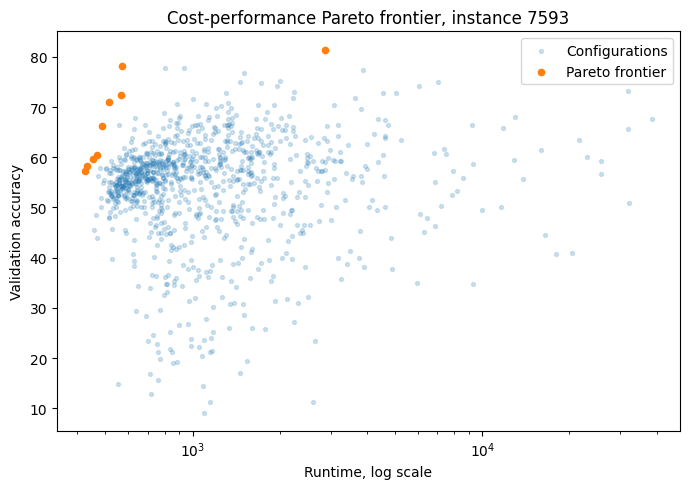

In [13]:
instance = "7593"
g = df[df["instance"].astype(str) == instance]
front = pareto_frontier(g)

plt.figure(figsize=(7, 5))
plt.scatter(g["time"], g["val_accuracy"], alpha=0.2, s=8, label="Configurations")
plt.scatter(front["time"], front["val_accuracy"], s=20, label="Pareto frontier")
plt.xscale("log")
plt.xlabel("Runtime, log scale")
plt.ylabel("Validation accuracy")
plt.title(f"Cost-performance Pareto frontier, instance {instance}")
plt.legend()
plt.tight_layout()
plt.show()

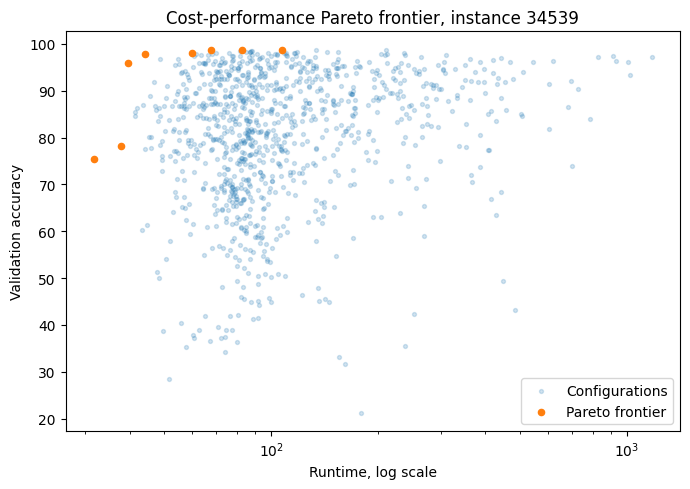

In [14]:
instance = "34539"
g = df[df["instance"].astype(str) == instance]
front = pareto_frontier(g)

plt.figure(figsize=(7, 5))
plt.scatter(g["time"], g["val_accuracy"], alpha=0.2, s=8, label="Configurations")
plt.scatter(front["time"], front["val_accuracy"], s=20, label="Pareto frontier")
plt.xscale("log")
plt.xlabel("Runtime, log scale")
plt.ylabel("Validation accuracy")
plt.title(f"Cost-performance Pareto frontier, instance {instance}")
plt.legend()
plt.tight_layout()
plt.show()

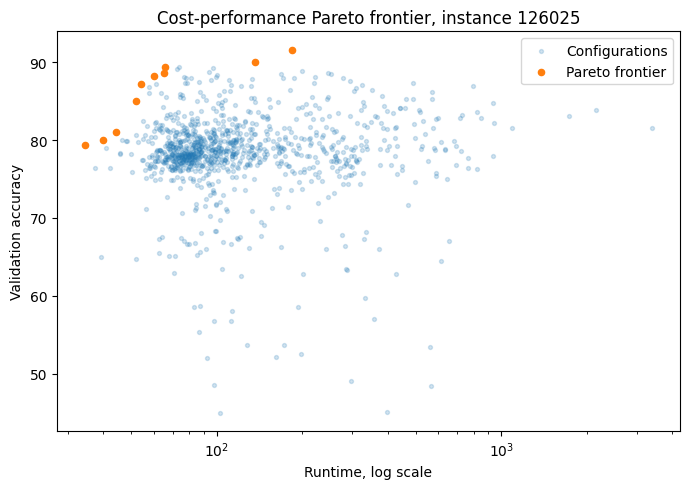

In [15]:
instance = "126025"
g = df[df["instance"].astype(str) == instance]
front = pareto_frontier(g)

plt.figure(figsize=(7, 5))
plt.scatter(g["time"], g["val_accuracy"], alpha=0.2, s=8, label="Configurations")
plt.scatter(front["time"], front["val_accuracy"], s=20, label="Pareto frontier")
plt.xscale("log")
plt.xlabel("Runtime, log scale")
plt.ylabel("Validation accuracy")
plt.title(f"Cost-performance Pareto frontier, instance {instance}")
plt.legend()
plt.tight_layout()
plt.show()

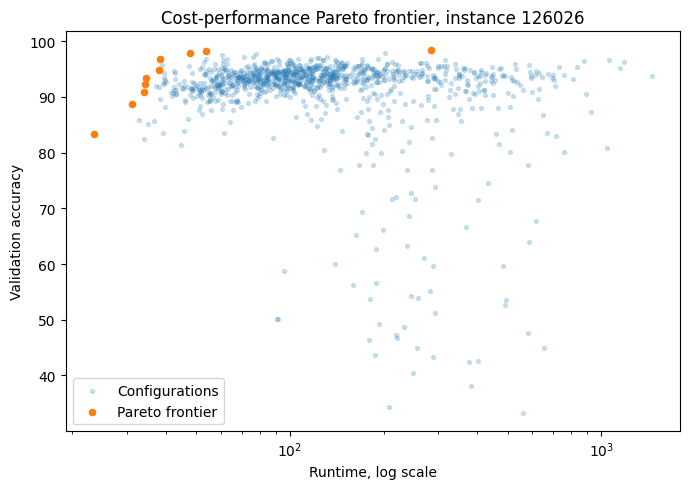

In [16]:
instance = "126026"
g = df[df["instance"].astype(str) == instance]
front = pareto_frontier(g)

plt.figure(figsize=(7, 5))
plt.scatter(g["time"], g["val_accuracy"], alpha=0.2, s=8, label="Configurations")
plt.scatter(front["time"], front["val_accuracy"], s=20, label="Pareto frontier")
plt.xscale("log")
plt.xlabel("Runtime, log scale")
plt.ylabel("Validation accuracy")
plt.title(f"Cost-performance Pareto frontier, instance {instance}")
plt.legend()
plt.tight_layout()
plt.show()

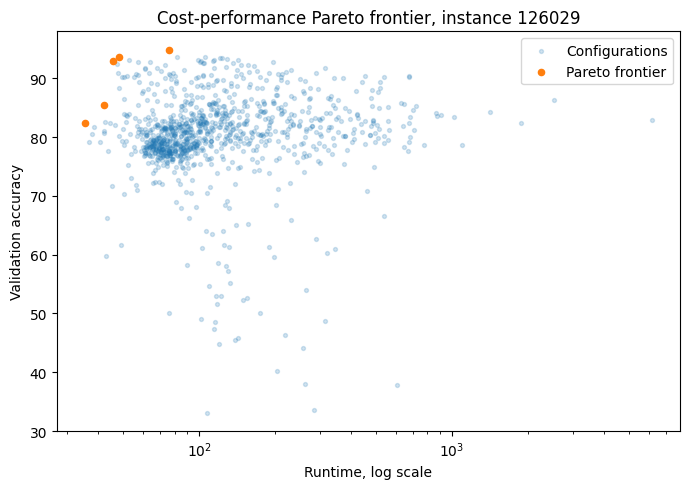

In [17]:
instance = "126029"
g = df[df["instance"].astype(str) == instance]
front = pareto_frontier(g)

plt.figure(figsize=(7, 5))
plt.scatter(g["time"], g["val_accuracy"], alpha=0.2, s=8, label="Configurations")
plt.scatter(front["time"], front["val_accuracy"], s=20, label="Pareto frontier")
plt.xscale("log")
plt.xlabel("Runtime, log scale")
plt.ylabel("Validation accuracy")
plt.title(f"Cost-performance Pareto frontier, instance {instance}")
plt.legend()
plt.tight_layout()
plt.show()

&nbsp;

&nbsp;

##### Hyperparameter impact on cost

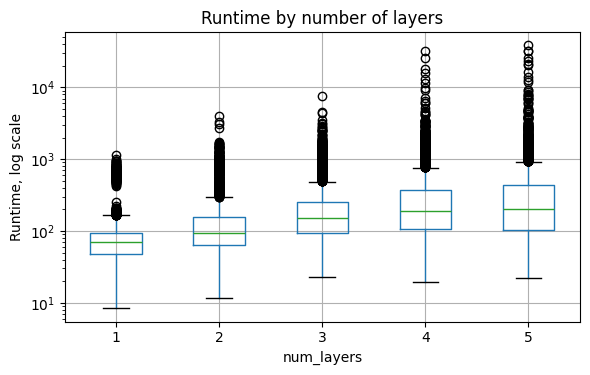

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))
df.boxplot(column="time", by="num_layers", ax=ax)
ax.set_yscale("log")
ax.set_title("Runtime by number of layers")
ax.set_xlabel("num_layers")
ax.set_ylabel("Runtime, log scale")
plt.suptitle("")
plt.tight_layout()
plt.show()

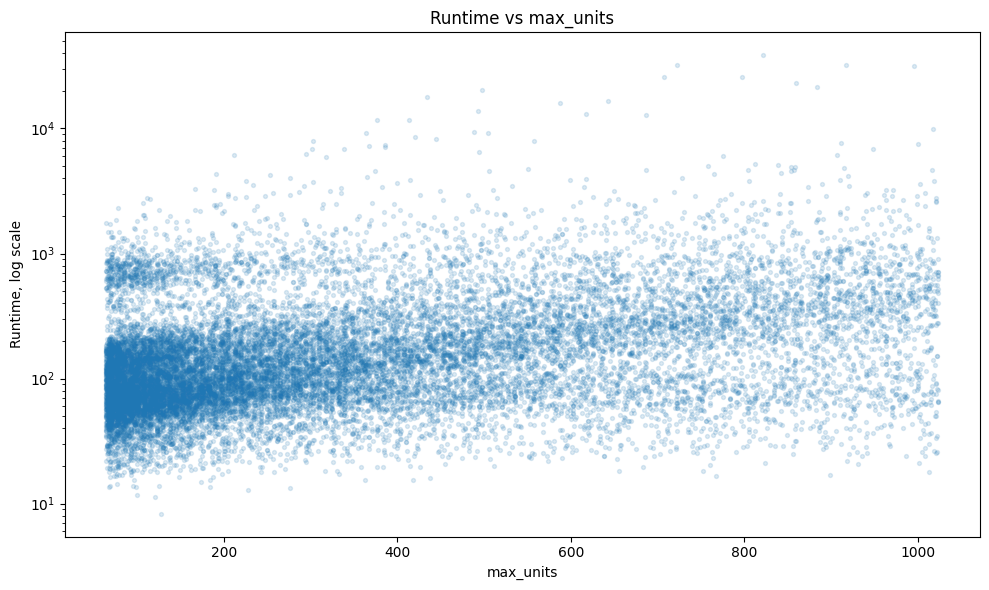

In [19]:
plt.figure(figsize=(10, 6))
plt.scatter(df["max_units"], df["time"], alpha=0.15, s=8)
plt.yscale("log")
plt.xlabel("max_units")
plt.ylabel("Runtime, log scale")
plt.title("Runtime vs max_units")
plt.tight_layout()
plt.show()

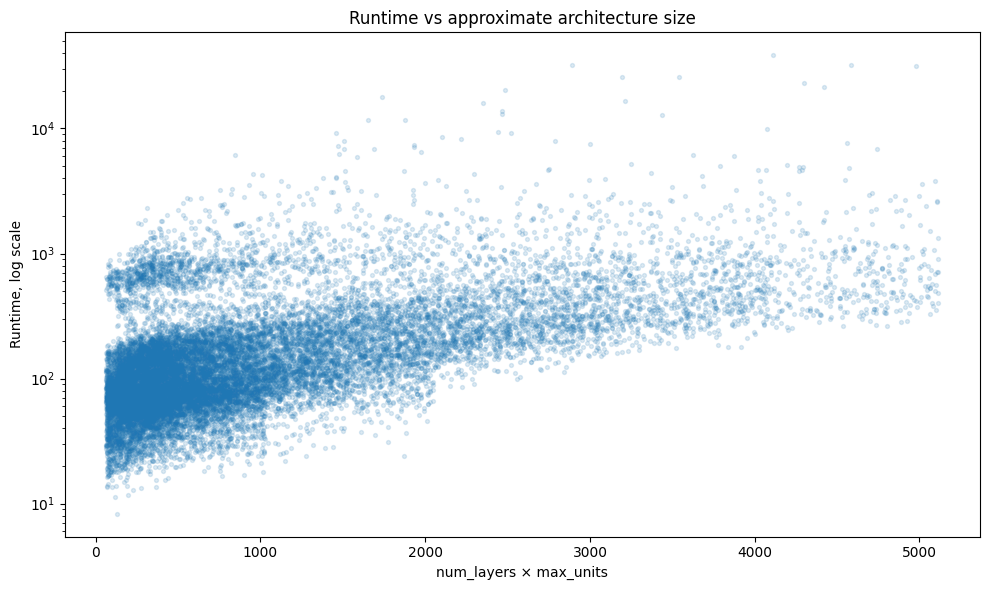

In [20]:
df["architecture_size"] = df["num_layers"] * df["max_units"]

plt.figure(figsize=(10, 6))
plt.scatter(df["architecture_size"], df["time"], alpha=0.15, s=8)
plt.yscale("log")
plt.xlabel("num_layers × max_units")
plt.ylabel("Runtime, log scale")
plt.title("Runtime vs approximate architecture size")
plt.tight_layout()
plt.show()

&nbsp;

&nbsp;

##### Validation accuracy distribution:

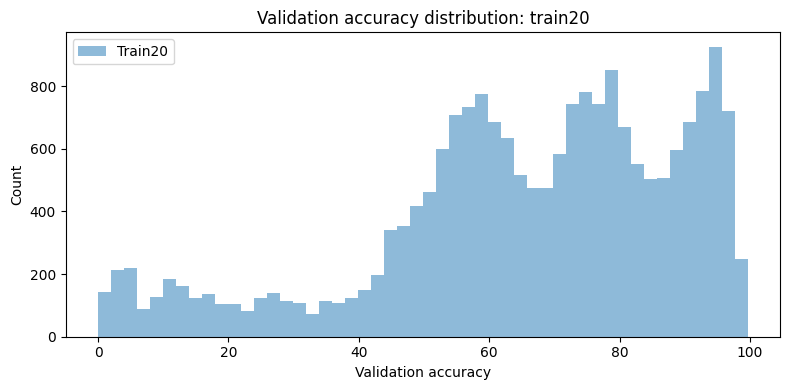

In [21]:
plt.figure(figsize=(8, 4))
plt.hist(df["val_accuracy"], bins=50, alpha=0.5, label="Train20")
plt.xlabel("Validation accuracy")
plt.ylabel("Count")
plt.title("Validation accuracy distribution: train20")
plt.legend()
plt.tight_layout()
plt.show()